# Bank Customer Churn - Exploratory Data Analysis
**Dataset:** Bank_Churn.csv | **10,000 rows x 13 columns** | **Churn rate: 20.37%**

**Business Problem:** The bank is losing 1 in 5 customers. and this identifies *who* is churning, *why*, and surfaces actionable patterns for retention strategy.

### Table of Contents
1. Setup & Data Loading
2. Data Overview & Quality Check
3. Target Variable: Churn Distribution
4. Univariate Analysis - Numerical Features
5. Univariate Analysis - Categorical Features
6. Bivariate Analysis - Churn vs Each Feature
7. Correlation Heatmap
8. Segment Deep-Dive (Age x Geography x Gender)
9. High-Value At-Risk Customers
10. Business Insights Summary


## 1. Setup & Data Loading

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : '#F8F9FA',
    'axes.grid'         : True,
    'grid.color'        : 'white',
    'grid.linewidth'    : 0.8,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'font.size'         : 11,
})

CHURN_COLORS  = ['#4C9BE8', '#E85C5C']
GEO_COLORS    = ['#4C9BE8', '#F5A623', '#7ED321']
GENDER_COLORS = ['#6C8EBF', '#E8A0BF']

df = pd.read_csv("C:/Users/siddh/Downloads/Bank+Customer+Churn/Bank_churn.csv")
print(f"Shape : {df.shape}")
print(f"Columns : {df.columns.tolist()}")
df.head()


Shape : (10000, 13)
Columns : ['CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 2. Data Overview & Quality Check

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  str    
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  str    
 4   Gender           10000 non-null  str    
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), str(3)
memory usage: 1015.8 KB


In [ ]:
df.describe().round(2)

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.0
mean,15690940.57,650.53,38.92,5.01,76485.89,1.53,0.71,0.52,100090.24,0.2
std,71936.19,96.65,10.49,2.89,62397.41,0.58,0.46,0.50,57510.49,0.4
min,15565701.00,350.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.0
25%,15628528.25,584.00,32.00,3.00,0.00,1.00,0.00,0.00,51002.11,0.0
50%,15690738.00,652.00,37.00,5.00,97198.54,1.00,1.00,1.00,100193.92,0.0
75%,15753233.75,718.00,44.00,7.00,127644.24,2.00,1.00,1.00,149388.25,0.0
max,15815690.00,850.00,92.00,10.00,250898.09,4.00,1.00,1.00,199992.48,1.0


In [ ]:
null_df = pd.DataFrame({
    'Missing Count' : df.isnull().sum(),
    'Missing %'     : (df.isnull().sum() / len(df) * 100).round(2)
})
print(null_df)
print("\nNo missing values - dataset is clean.")


                 Missing Count  Missing %
CustomerId                   0        0.0
Surname                      0        0.0
CreditScore                  0        0.0
Geography                    0        0.0
Gender                       0        0.0
Age                          0        0.0
Tenure                       0        0.0
Balance                      0        0.0
NumOfProducts                0        0.0
HasCrCard                    0        0.0
IsActiveMember               0        0.0
EstimatedSalary              0        0.0
Exited                       0        0.0

No missing values - dataset is clean.


In [ ]:
print(f"Duplicate rows: {df.duplicated().sum()}")
df.drop(columns=['CustomerId', 'Surname'], inplace=True)
print(f"Working shape after dropping PII: {df.shape}")


Duplicate rows: 0
Working shape after dropping PII: (10000, 11)


## 3. Target Variable - Churn Distribution

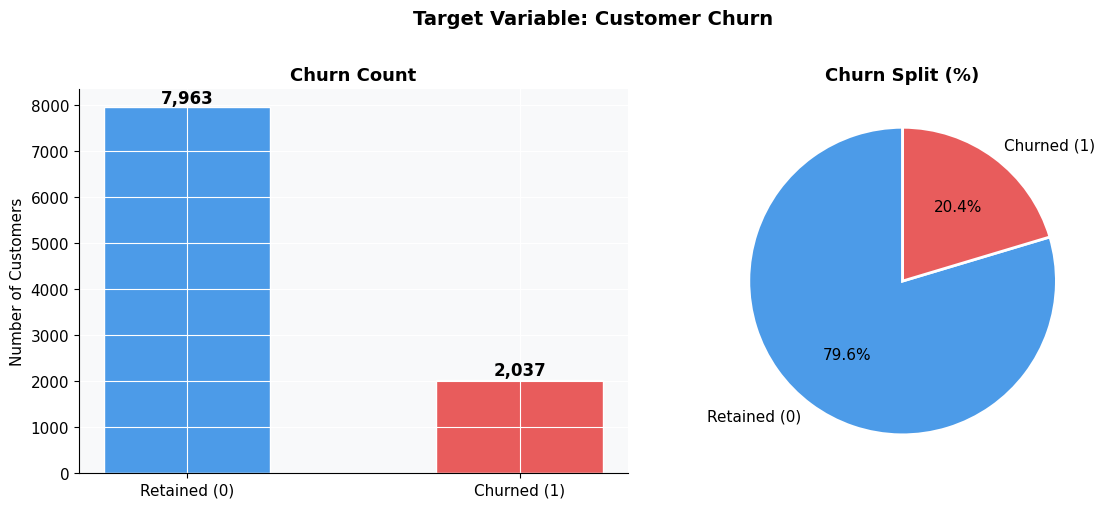

Churn rate: 20.37%  ->  dataset is imbalanced (80/20 split)


In [ ]:
churn_counts = df['Exited'].value_counts()
churn_labels = ['Retained (0)', 'Churned (1)']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(churn_labels, churn_counts.values, color=CHURN_COLORS, width=0.5, edgecolor='white')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 80, f'{v:,}', ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Churn Count', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Number of Customers')

axes[1].pie(
    churn_counts.values,
    labels=churn_labels,
    colors=CHURN_COLORS,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Churn Split (%)', fontweight='bold', fontsize=13)

plt.suptitle('Target Variable: Customer Churn', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('01_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Churn rate: {df['Exited'].mean()*100:.2f}%  ->  dataset is imbalanced (80/20 split)")


## 4. Univariate Analysis - Numerical Features

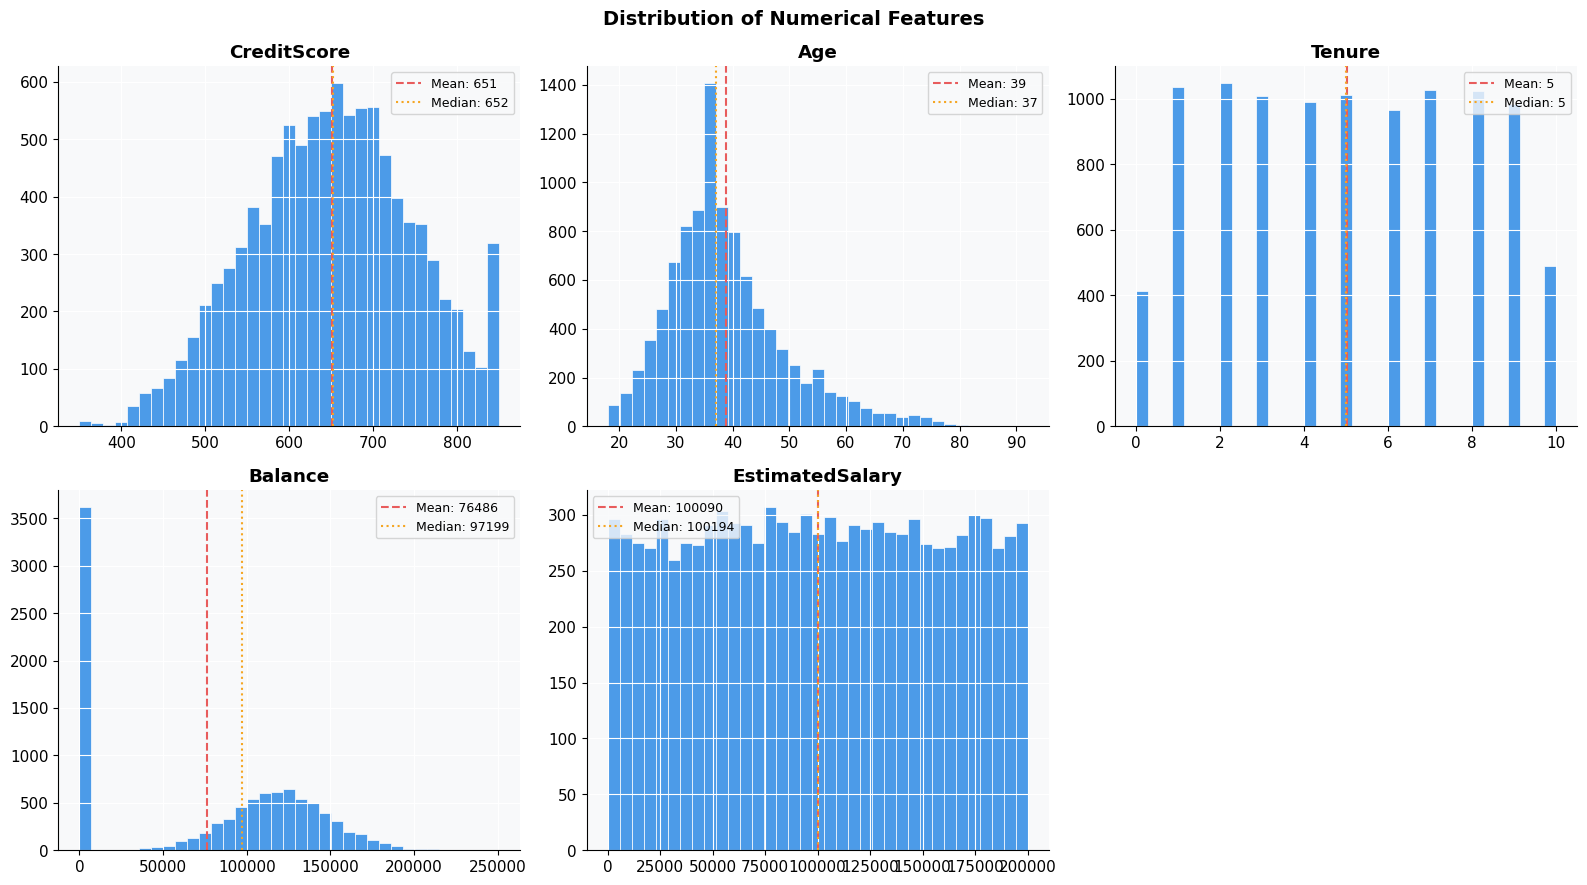

In [ ]:
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=35, color='#4C9BE8', edgecolor='white', linewidth=0.5)
    axes[i].axvline(df[col].mean(),   color='#E85C5C', linestyle='--', linewidth=1.5, label=f'Mean: {df[col].mean():.0f}')
    axes[i].axvline(df[col].median(), color='#F5A623', linestyle=':',  linewidth=1.5, label=f'Median: {df[col].median():.0f}')
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=9)

axes[5].axis('off')
plt.suptitle('Distribution of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('02_numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


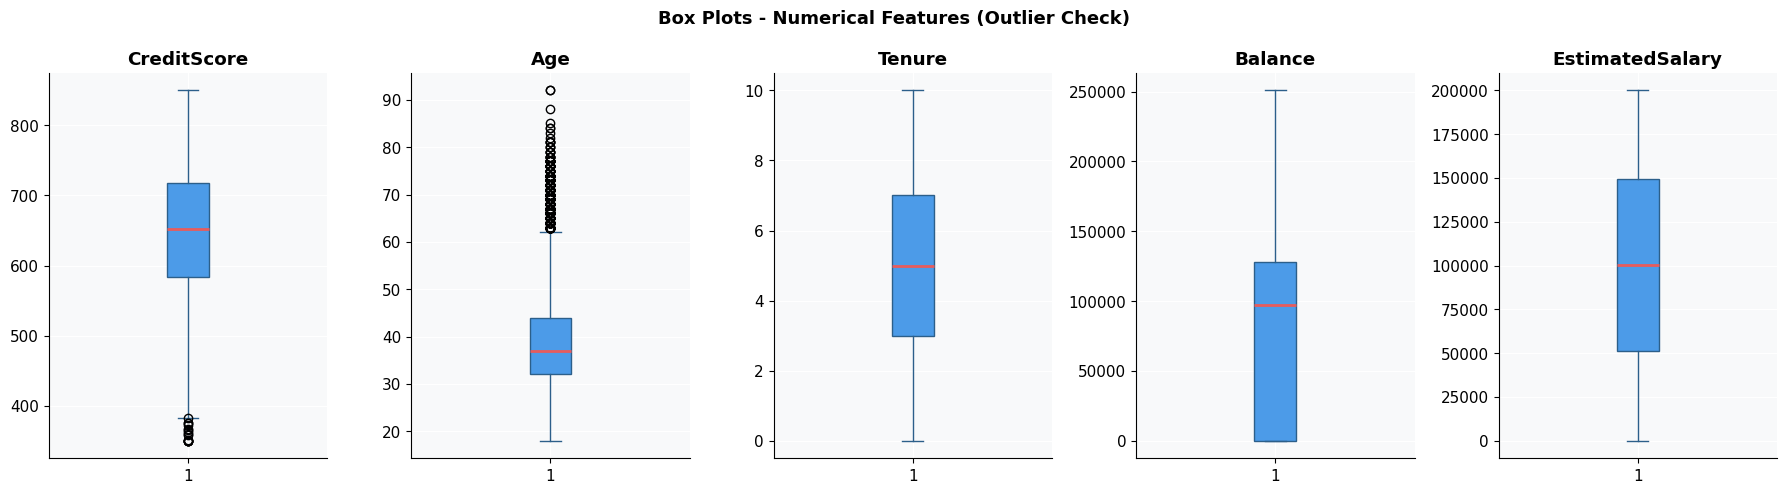

Max age: 92  | Customers aged 70+: 151


In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='#4C9BE8', color='#2C5F8A'),
                    medianprops=dict(color='#E85C5C', linewidth=2),
                    whiskerprops=dict(color='#2C5F8A'),
                    capprops=dict(color='#2C5F8A'))
    axes[i].set_title(col, fontweight='bold')

plt.suptitle('Box Plots - Numerical Features (Outlier Check)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('03_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Max age: {df['Age'].max()}  | Customers aged 70+: {(df['Age'] >= 70).sum()}")


## 5. Univariate Analysis - Categorical Features

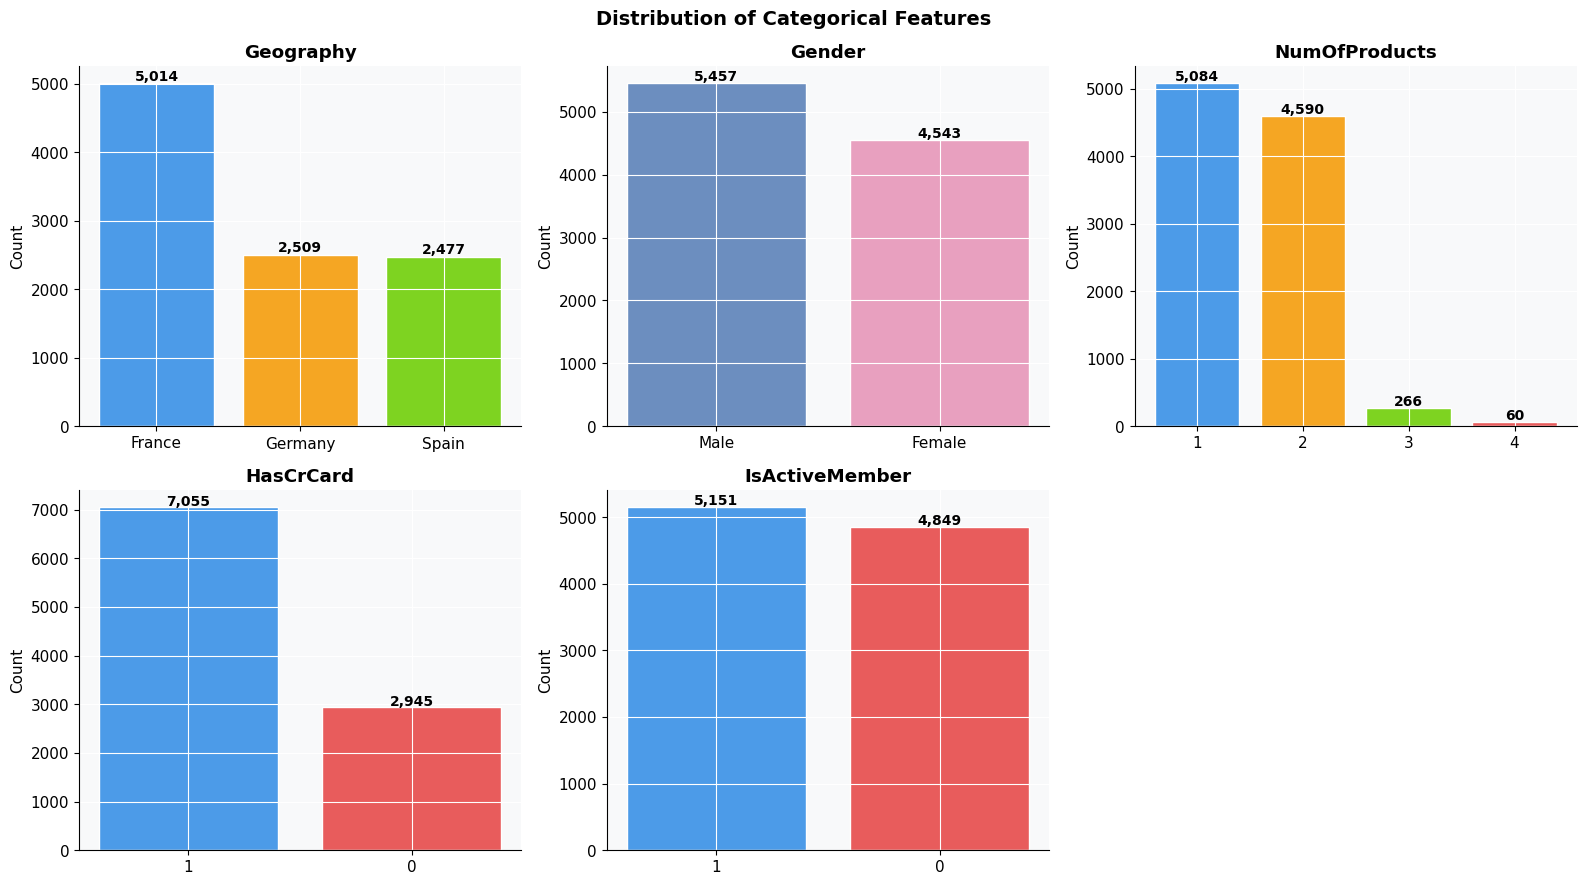

In [ ]:
cat_cols = {
    'Geography'      : GEO_COLORS,
    'Gender'         : GENDER_COLORS,
    'NumOfProducts'  : ['#4C9BE8','#F5A623','#7ED321','#E85C5C'],
    'HasCrCard'      : CHURN_COLORS,
    'IsActiveMember' : CHURN_COLORS,
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (col, colors) in enumerate(cat_cols.items()):
    vc = df[col].value_counts()
    axes[i].bar(vc.index.astype(str), vc.values, color=colors[:len(vc)], edgecolor='white')
    for j, v in enumerate(vc.values):
        axes[i].text(j, v + 40, f'{v:,}', ha='center', fontsize=10, fontweight='bold')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Count')

axes[5].axis('off')
plt.suptitle('Distribution of Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('04_categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Bivariate Analysis - Churn vs Each Feature

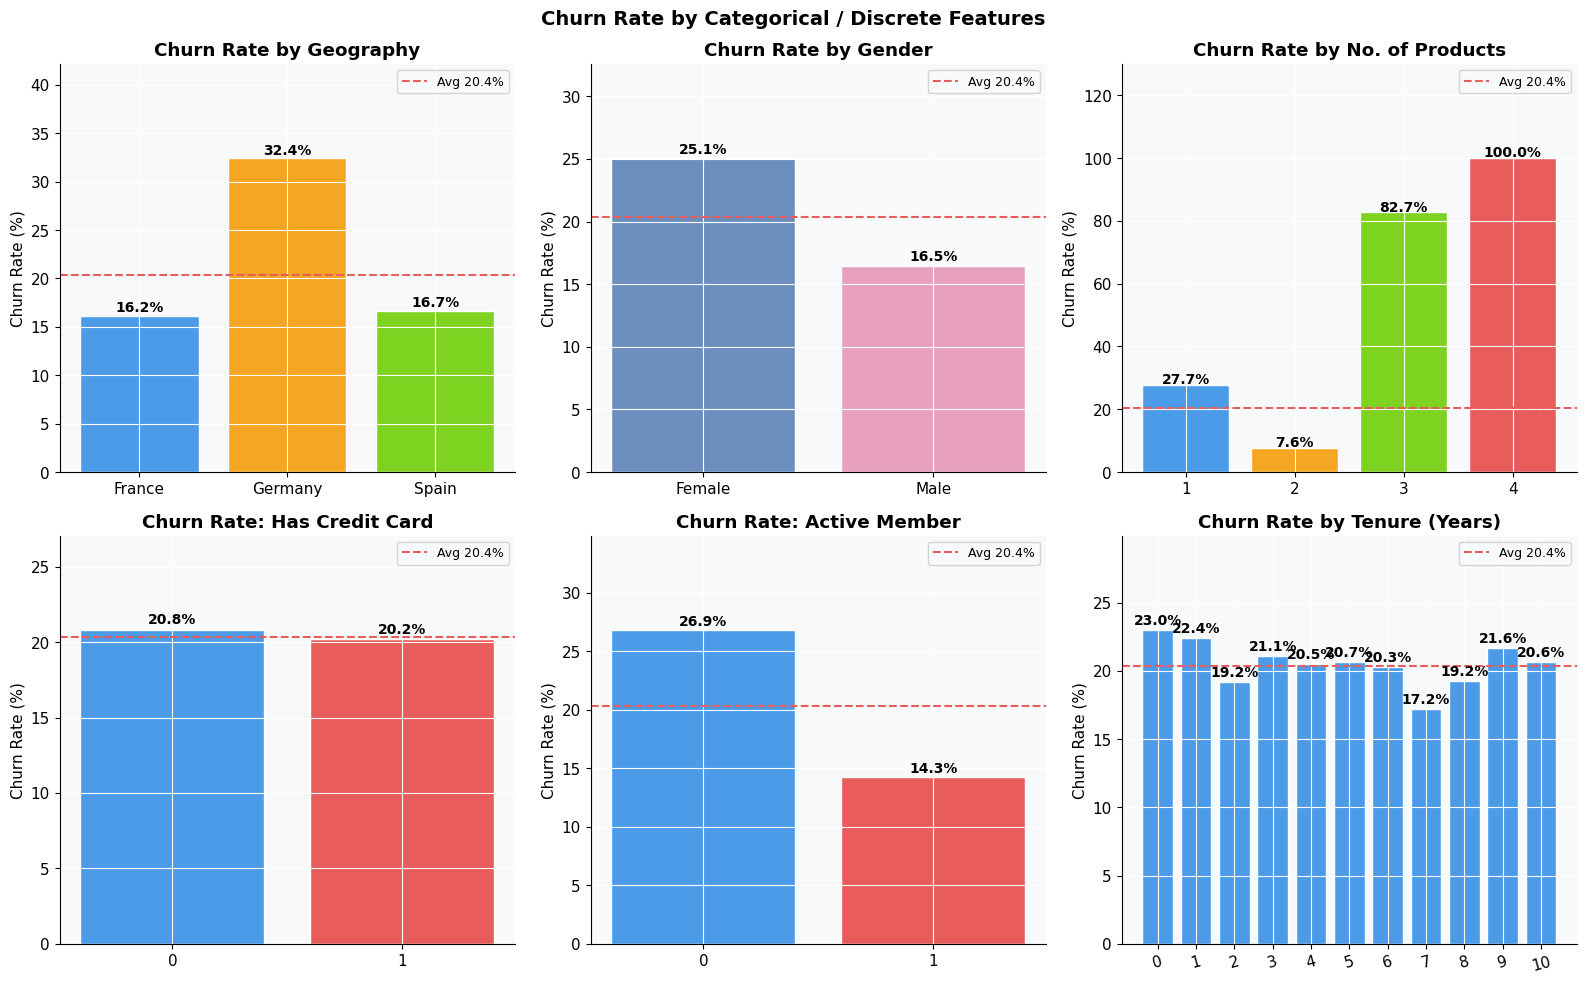

In [ ]:
def churn_rate_bar(ax, col, title, colors=None, rotate=False):
    cr = df.groupby(col)['Exited'].mean().mul(100).reset_index()
    cr.columns = [col, 'Churn Rate (%)']
    bars = ax.bar(cr[col].astype(str), cr['Churn Rate (%)'],
                  color=colors if colors else '#4C9BE8', edgecolor='white')
    for bar, val in zip(bars, cr['Churn Rate (%)']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
    ax.axhline(df['Exited'].mean()*100, color='#E85C5C',
               linestyle='--', linewidth=1.5, label=f'Avg {df["Exited"].mean()*100:.1f}%')
    ax.legend(fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_ylim(0, cr['Churn Rate (%)'].max() * 1.3)
    if rotate:
        ax.tick_params(axis='x', rotation=15)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
churn_rate_bar(axes[0,0], 'Geography',      'Churn Rate by Geography',       GEO_COLORS)
churn_rate_bar(axes[0,1], 'Gender',         'Churn Rate by Gender',          GENDER_COLORS)
churn_rate_bar(axes[0,2], 'NumOfProducts',  'Churn Rate by No. of Products', ['#4C9BE8','#F5A623','#7ED321','#E85C5C'])
churn_rate_bar(axes[1,0], 'HasCrCard',      'Churn Rate: Has Credit Card',   CHURN_COLORS)
churn_rate_bar(axes[1,1], 'IsActiveMember', 'Churn Rate: Active Member',     CHURN_COLORS)
churn_rate_bar(axes[1,2], 'Tenure',         'Churn Rate by Tenure (Years)',  rotate=True)

plt.suptitle('Churn Rate by Categorical / Discrete Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('05_churn_by_category.png', dpi=150, bbox_inches='tight')
plt.show()


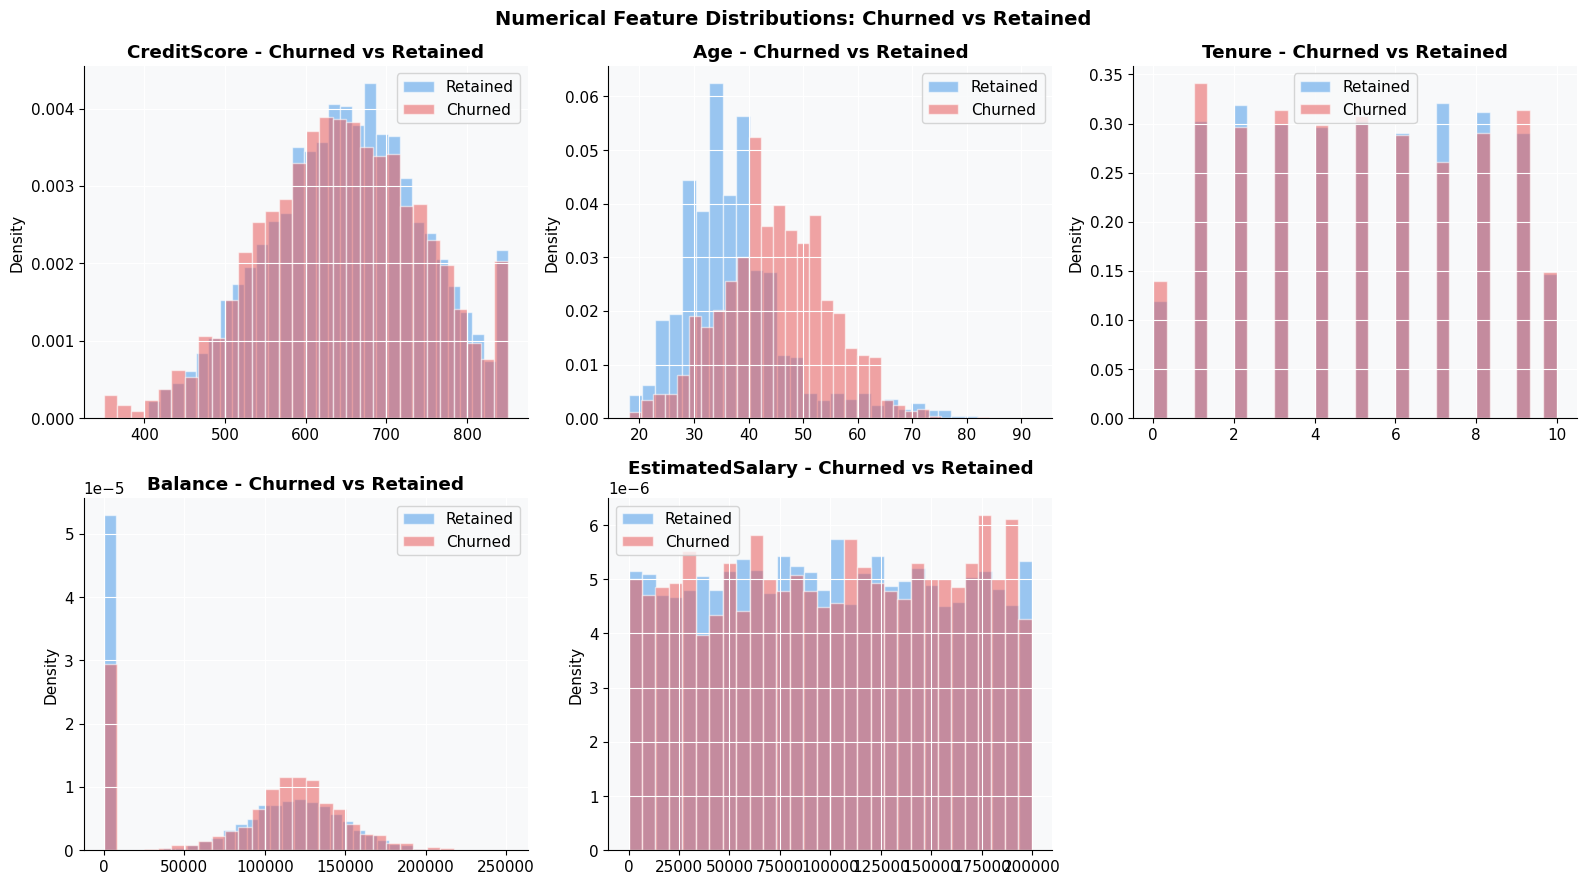

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    retained = df[df['Exited']==0][col]
    churned  = df[df['Exited']==1][col]
    axes[i].hist(retained, bins=30, alpha=0.55, color=CHURN_COLORS[0],
                 edgecolor='white', label='Retained', density=True)
    axes[i].hist(churned,  bins=30, alpha=0.55, color=CHURN_COLORS[1],
                 edgecolor='white', label='Churned',  density=True)
    axes[i].set_title(f'{col} - Churned vs Retained', fontweight='bold')
    axes[i].legend()
    axes[i].set_ylabel('Density')

axes[5].axis('off')
plt.suptitle('Numerical Feature Distributions: Churned vs Retained', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('06_kde_churned_vs_retained.png', dpi=150, bbox_inches='tight')
plt.show()


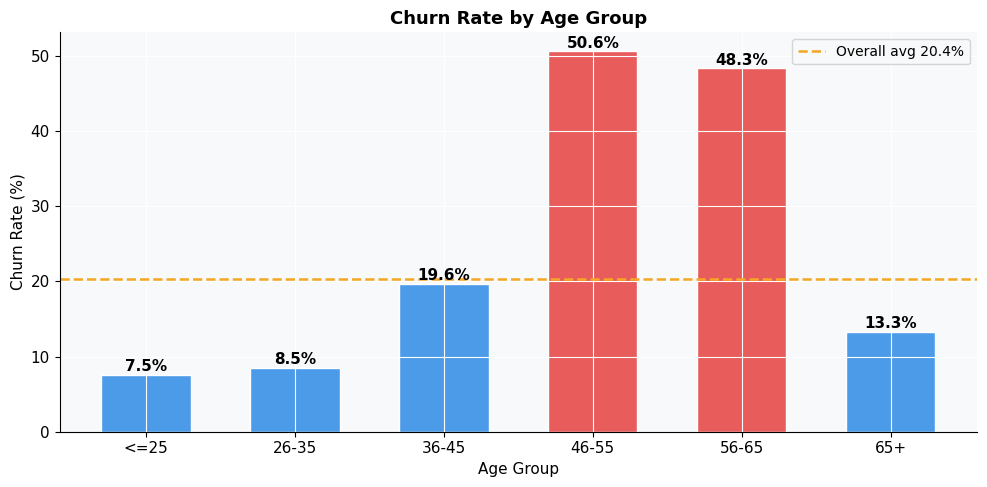

AgeGroup
46-55    50.572082
56-65    48.320896
36-45    19.619914
65+      13.257576
26-35     8.498024
<=25      7.528642
Name: Exited, dtype: float64


In [ ]:
df['AgeGroup'] = pd.cut(df['Age'],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=['<=25', '26-35', '36-45', '46-55', '56-65', '65+'])

cr_age = df.groupby('AgeGroup', observed=True)['Exited'].mean().mul(100)

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ['#E85C5C' if v > df['Exited'].mean()*100 else '#4C9BE8' for v in cr_age.values]
bars = ax.bar(cr_age.index.astype(str), cr_age.values, color=bar_colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, cr_age.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.axhline(df['Exited'].mean()*100, color='#F5A623',
           linestyle='--', linewidth=1.8, label=f'Overall avg {df["Exited"].mean()*100:.1f}%')
ax.legend(fontsize=10)
ax.set_title('Churn Rate by Age Group', fontweight='bold', fontsize=13)
ax.set_xlabel('Age Group')
ax.set_ylabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig('07_churn_by_agegroup.png', dpi=150, bbox_inches='tight')
plt.show()
print(cr_age.sort_values(ascending=False))


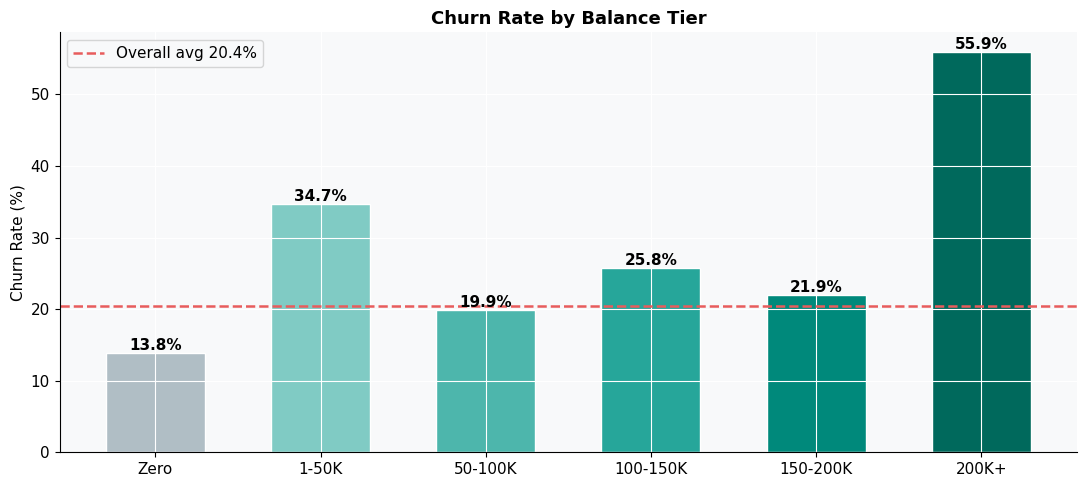

In [ ]:
df['BalanceTier'] = pd.cut(df['Balance'],
    bins=[-1, 0, 50000, 100000, 150000, 200000, 300000],
    labels=['Zero', '1-50K', '50-100K', '100-150K', '150-200K', '200K+'])

cr_bal = df.groupby('BalanceTier', observed=True)['Exited'].mean().mul(100)

fig, ax = plt.subplots(figsize=(11, 5))
colors_bal = ['#B0BEC5','#80CBC4','#4DB6AC','#26A69A','#00897B','#00695C']
bars = ax.bar(cr_bal.index.astype(str), cr_bal.values, color=colors_bal, edgecolor='white', width=0.6)
for bar, val in zip(bars, cr_bal.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.axhline(df['Exited'].mean()*100, color='#E85C5C',
           linestyle='--', linewidth=1.8, label=f'Overall avg {df["Exited"].mean()*100:.1f}%')
ax.legend()
ax.set_title('Churn Rate by Balance Tier', fontweight='bold', fontsize=13)
ax.set_ylabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig('08_churn_by_balance.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Correlation Heatmap

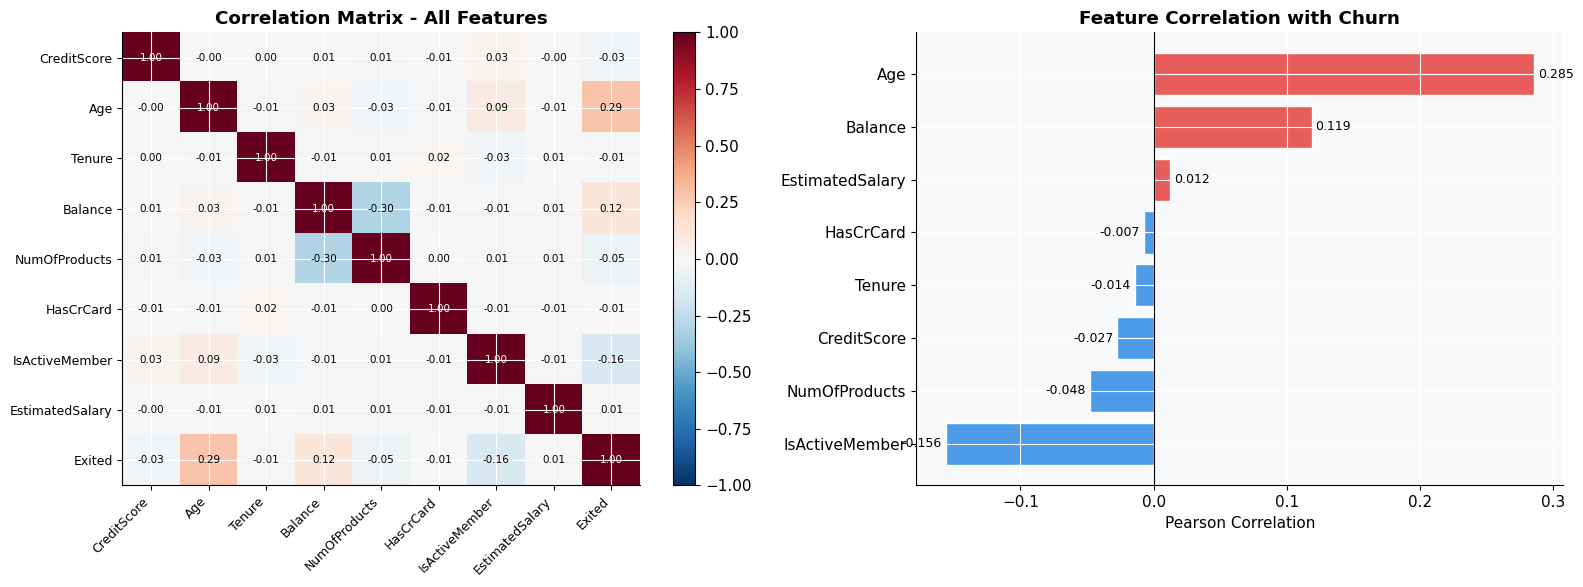

Positive correlators with churn:
Age                0.285323
Balance            0.118533
EstimatedSalary    0.012097


In [ ]:
corr_matrix      = df.select_dtypes(include='number').corr()
corr_with_churn  = corr_matrix['Exited'].drop('Exited').sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

im = axes[0].imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
axes[0].set_xticks(range(len(corr_matrix.columns)))
axes[0].set_yticks(range(len(corr_matrix.columns)))
axes[0].set_xticklabels(corr_matrix.columns, rotation=45, ha='right', fontsize=9)
axes[0].set_yticklabels(corr_matrix.columns, fontsize=9)
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        v = corr_matrix.values[i, j]
        axes[0].text(j, i, f'{v:.2f}', ha='center', va='center',
                     fontsize=7.5, color='white' if abs(v) > 0.4 else 'black')
plt.colorbar(im, ax=axes[0])
axes[0].set_title('Correlation Matrix - All Features', fontweight='bold')

colors_corr = ['#E85C5C' if v > 0 else '#4C9BE8' for v in corr_with_churn.values]
axes[1].barh(corr_with_churn.index, corr_with_churn.values, color=colors_corr, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
for i, v in enumerate(corr_with_churn.values):
    axes[1].text(v + (0.003 if v >= 0 else -0.003), i, f'{v:.3f}',
                 va='center', ha='left' if v >= 0 else 'right', fontsize=9)
axes[1].set_title('Feature Correlation with Churn', fontweight='bold')
axes[1].set_xlabel('Pearson Correlation')

plt.tight_layout()
plt.savefig('09_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("Positive correlators with churn:")
print(corr_with_churn[corr_with_churn > 0].sort_values(ascending=False).to_string())


## 8. Segment Deep-Dive - Age x Geography x Gender

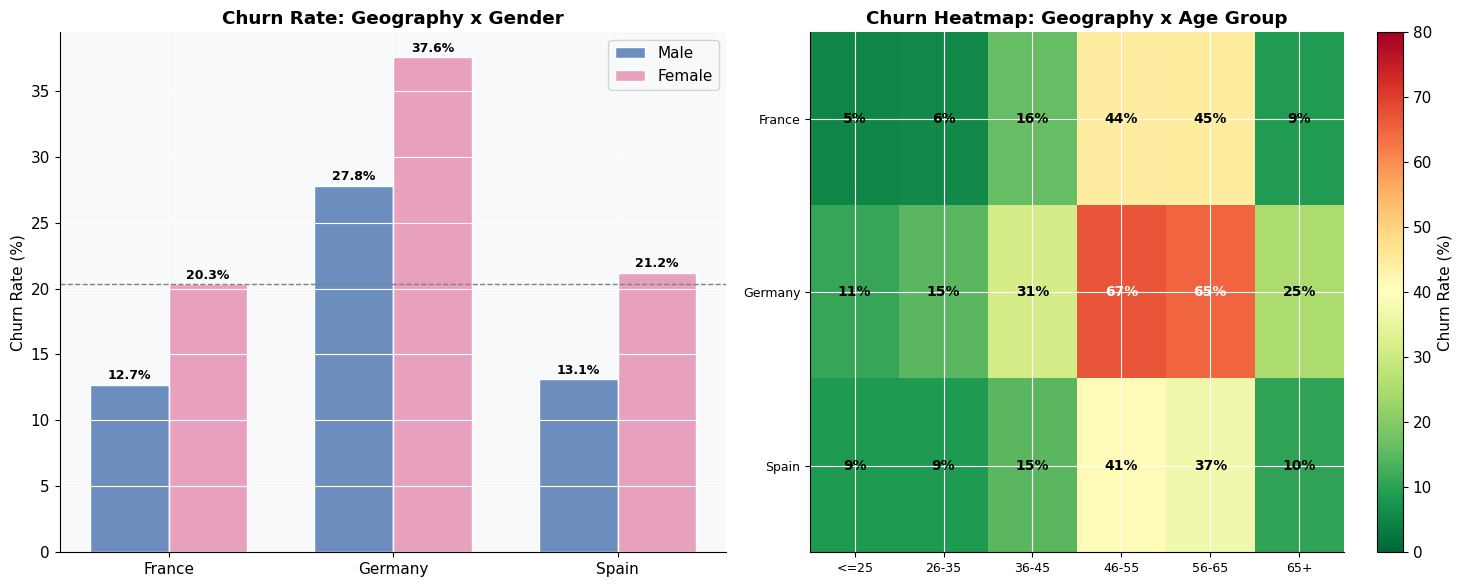

In [ ]:
pivot = df.groupby(['Geography','Gender'])['Exited'].mean().mul(100).unstack()

x      = np.arange(len(pivot.index))
width  = 0.35

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

b1 = axes[0].bar(x - width/2, pivot['Male'],   width, label='Male',   color=GENDER_COLORS[0], edgecolor='white')
b2 = axes[0].bar(x + width/2, pivot['Female'], width, label='Female', color=GENDER_COLORS[1], edgecolor='white')
for bar in list(b1) + list(b2):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(pivot.index)
axes[0].set_title('Churn Rate: Geography x Gender', fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].legend()
axes[0].axhline(df['Exited'].mean()*100, color='grey', linestyle='--', linewidth=1)

heat = df.groupby(['Geography','AgeGroup'], observed=True)['Exited'].mean().mul(100).unstack()
im2  = axes[1].imshow(heat.values, cmap='RdYlGn_r', vmin=0, vmax=80, aspect='auto')
axes[1].set_xticks(range(len(heat.columns)))
axes[1].set_yticks(range(len(heat.index)))
axes[1].set_xticklabels(heat.columns, fontsize=9)
axes[1].set_yticklabels(heat.index, fontsize=9)
for i in range(len(heat.index)):
    for j in range(len(heat.columns)):
        val = heat.values[i, j]
        axes[1].text(j, i, f'{val:.0f}%', ha='center', va='center',
                     fontsize=10, fontweight='bold',
                     color='white' if val > 50 else 'black')
plt.colorbar(im2, ax=axes[1], label='Churn Rate (%)')
axes[1].set_title('Churn Heatmap: Geography x Age Group', fontweight='bold')

plt.tight_layout()
plt.savefig('10_segment_deepdive.png', dpi=150, bbox_inches='tight')
plt.show()


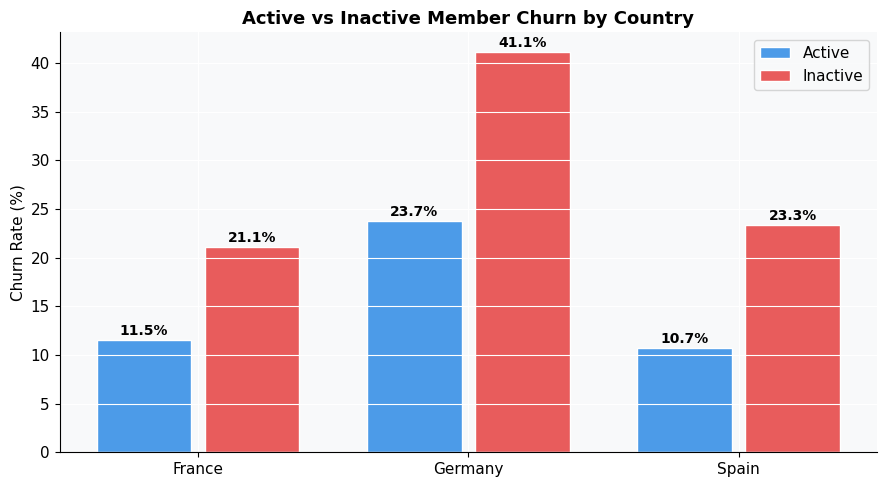

In [ ]:
pivot2 = df.groupby(['Geography','IsActiveMember'])['Exited'].mean().mul(100).unstack()
pivot2.columns = ['Inactive', 'Active']

x2  = np.arange(len(pivot2))
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x2 - 0.2, pivot2['Active'],   0.35, label='Active',   color='#4C9BE8', edgecolor='white')
b2 = ax.bar(x2 + 0.2, pivot2['Inactive'], 0.35, label='Inactive', color='#E85C5C', edgecolor='white')
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(x2)
ax.set_xticklabels(pivot2.index)
ax.set_title('Active vs Inactive Member Churn by Country', fontweight='bold', fontsize=13)
ax.set_ylabel('Churn Rate (%)')
ax.legend()
plt.tight_layout()
plt.savefig('11_active_vs_inactive.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. High-Value At-Risk Customers

In [ ]:
high_value_churned = df[
    (df['Balance'] >= df['Balance'].quantile(0.75)) &
    (df['Exited']  == 1)
].copy()

print(f"High-value churned customers : {len(high_value_churned)}")
print(f"Avg balance                  : ${high_value_churned['Balance'].mean():,.0f}")
print(f"Avg age                      : {high_value_churned['Age'].mean():.1f}")
print()
print("Geography breakdown:")
print(high_value_churned['Geography'].value_counts())
print()
print("Gender breakdown:")
print(high_value_churned['Gender'].value_counts())


High-value churned customers : 592
Avg balance                  : $149,755
Avg age                      : 44.3

Geography breakdown:
Geography
Germany    274
France     214
Spain      104
Name: count, dtype: int64

Gender breakdown:
Gender
Female    325
Male      267
Name: count, dtype: int64


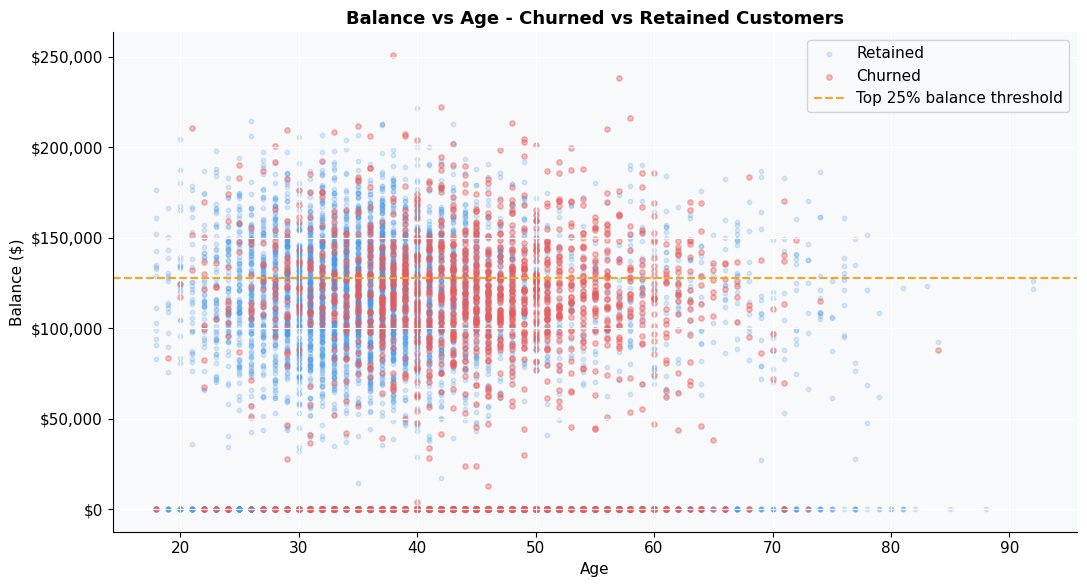

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))

retained = df[df['Exited']==0]
churned  = df[df['Exited']==1]

ax.scatter(retained['Age'], retained['Balance'], alpha=0.2, s=10,
           color=CHURN_COLORS[0], label='Retained')
ax.scatter(churned['Age'],  churned['Balance'],  alpha=0.4, s=15,
           color=CHURN_COLORS[1], label='Churned')
ax.axhline(df['Balance'].quantile(0.75), color='#F5A623', linestyle='--',
           linewidth=1.5, label='Top 25% balance threshold')
ax.set_xlabel('Age')
ax.set_ylabel('Balance ($)')
ax.set_title('Balance vs Age - Churned vs Retained Customers', fontweight='bold', fontsize=13)
ax.legend()
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('12_scatter_balance_age.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Business Insights Summary

In [ ]:
inactive_churn = df[df['IsActiveMember']==0]['Exited'].mean()*100
active_churn   = df[df['IsActiveMember']==1]['Exited'].mean()*100
hv_churn       = df[df['Balance']>=df['Balance'].quantile(0.75)]['Exited'].mean()*100
zero_churn     = df[df['Balance']==0]['Exited'].mean()*100
hv_count       = len(df[(df['Balance']>=df['Balance'].quantile(0.75))&(df['Exited']==1)])

print("=" * 58)
print("  BANK CHURN - KEY BUSINESS INSIGHTS")
print("=" * 58)
print(f"  Overall churn rate              : {df['Exited'].mean()*100:.2f}%")
print(f"  Highest churn country           : Germany (~32%)")
print(f"  Highest churn gender            : Female (~25% vs Male ~16%)")
print(f"  Highest churn age group         : 46-55 (50%+)")
print(f"  Most dangerous product count    : 3-4 products (>80% churn)")
print(f"  Inactive member churn rate      : {inactive_churn:.1f}%")
print(f"  Active member churn rate        : {active_churn:.1f}%")
print(f"  Zero-balance customer churn     : {zero_churn:.1f}%")
print(f"  High-balance (top 25%) churn    : {hv_churn:.1f}%")
print(f"  High-value customers churned    : {hv_count}")
print("=" * 58)
print()
print("RECOMMENDATIONS")
print()
print("1. GERMANY PRIORITY  : 32% churn vs 16% France.")
print("   Investigate pricing, products, or service issues.")
print()
print("2. FEMALE RETENTION  : Women churn ~9pp more than men.")
print("   Launch targeted loyalty or reward programs.")
print()
print("3. AGE 46-55 ALERT   : Highest churn cohort.")
print("   Competitors may offer better wealth management products.")
print()
print("4. PRODUCT TRAP      : 3-4 product customers churn at 80%+.")
print("   Review onboarding and cross-sell strategy.")
print()
print("5. INACTIVE MEMBERS  : 26% churn vs 14% active.")
print("   Re-engagement campaigns can halve the risk.")
print()
print("6. HIGH-VALUE AT RISK: Top-quartile balance churners = biggest")
print("   revenue impact. Assign dedicated relationship managers.")


  BANK CHURN - KEY BUSINESS INSIGHTS
  Overall churn rate              : 20.37%
  Highest churn country           : Germany (~32%)
  Highest churn gender            : Female (~25% vs Male ~16%)
  Highest churn age group         : 46-55 (50%+)
  Most dangerous product count    : 3-4 products (>80% churn)
  Inactive member churn rate      : 26.9%
  Active member churn rate        : 14.3%
  Zero-balance customer churn     : 13.8%
  High-balance (top 25%) churn    : 23.7%
  High-value customers churned    : 592

RECOMMENDATIONS

1. GERMANY PRIORITY  : 32% churn vs 16% France.
   Investigate pricing, products, or service issues.

2. FEMALE RETENTION  : Women churn ~9pp more than men.
   Launch targeted loyalty or reward programs.

3. AGE 46-55 ALERT   : Highest churn cohort.
   Competitors may offer better wealth management products.

4. PRODUCT TRAP      : 3-4 product customers churn at 80%+.
   Review onboarding and cross-sell strategy.

5. INACTIVE MEMBERS  : 26% churn vs 14% active.
   